In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
"""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
"""

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

In [2]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.notebook import tqdm

In [3]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"
device = torch.device(device)

print(device)

cuda:0


# **Helper Functions**

In [4]:
def showImages(image_path,label_path,title = "Sample"):
    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("RGB")
    fig,ax = plt.subplots(1,2,figsize = (12,6))
    ax[0].imshow(image)
    ax[0].set_title(f"{title} Image")
    ax[0].axis('off')
    ax[1].imshow(mask)
    ax[1].set_title(f"{title} Mask")
    ax[1].axis('off')
    plt.show()

In [5]:
import torch.optim as optim
def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    num_epochs,
    device,
    num_classes,
    train_loss,
    train_acc,
    train_prec,
    train_recall,
    train_f1,
    train_iou,
    train_dice,
    val_loss,
    val_acc,
    val_prec,
    val_recall,
    val_f1,
    val_iou,
    val_dice,
    test_loss,
    test_acc,
    test_prec,
    test_recall,
    test_f1,
    test_iou,
    test_dice,
    lr=1e-4,
    save_dir="saved_models",
    monitor_metric="val_iou"
):

    os.makedirs(save_dir, exist_ok=True)
    device = torch.device(device)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_metric_val = -np.inf
    best_epoch = -1
    best_model_path = None

    for epoch in range(num_epochs):
        # ----- TRAIN -----
        model.train()
        epoch_train_loss = 0.0
        epoch_train_acc = 0.0
        epoch_train_prec = 0.0
        epoch_train_rec = 0.0
        epoch_train_f1 = 0.0
        epoch_train_iou = 0.0
        epoch_train_dice = 0.0

        for images, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            epoch_train_acc += accuracy_score_batch(preds, labels)
            epoch_train_prec += precision_score_batch(preds, labels, num_classes)
            epoch_train_rec += recall_score_batch(preds, labels, num_classes)
            epoch_train_f1 += f1_score_batch(preds, labels, num_classes)
            epoch_train_iou += iou_score_batch(preds, labels, num_classes)
            epoch_train_dice += dice_score_batch(preds, labels, num_classes)

        train_n = max(1, len(train_loader))
        train_loss.append(epoch_train_loss / train_n)
        train_acc.append(epoch_train_acc / train_n)
        train_prec.append(epoch_train_prec / train_n)
        train_recall.append(epoch_train_rec / train_n)
        train_f1.append(epoch_train_f1 / train_n)
        train_iou.append(epoch_train_iou / train_n)
        train_dice.append(epoch_train_dice / train_n)

        # ----- VALIDATION -----
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_acc = 0.0
        epoch_val_prec = 0.0
        epoch_val_rec = 0.0
        epoch_val_f1 = 0.0
        epoch_val_iou = 0.0
        epoch_val_dice = 0.0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Val Epoch {epoch+1}", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                epoch_val_acc += accuracy_score_batch(preds, labels)
                epoch_val_prec += precision_score_batch(preds, labels, num_classes)
                epoch_val_rec += recall_score_batch(preds, labels, num_classes)
                epoch_val_f1 += f1_score_batch(preds, labels, num_classes)
                epoch_val_iou += iou_score_batch(preds, labels, num_classes)
                epoch_val_dice += dice_score_batch(preds, labels, num_classes)

        val_n = max(1, len(val_loader))
        val_loss.append(epoch_val_loss / val_n)
        val_acc.append(epoch_val_acc / val_n)
        val_prec.append(epoch_val_prec / val_n)
        val_recall.append(epoch_val_rec / val_n)
        val_f1.append(epoch_val_f1 / val_n)
        val_iou.append(epoch_val_iou / val_n)
        val_dice.append(epoch_val_dice / val_n)

        # ----- TEST -----
        epoch_test_loss = 0.0
        epoch_test_acc = 0.0
        epoch_test_prec = 0.0
        epoch_test_rec = 0.0
        epoch_test_f1 = 0.0
        epoch_test_iou = 0.0
        epoch_test_dice = 0.0

        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Test Epoch {epoch+1}", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_test_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                epoch_test_acc += accuracy_score_batch(preds, labels)
                epoch_test_prec += precision_score_batch(preds, labels, num_classes)
                epoch_test_rec += recall_score_batch(preds, labels, num_classes)
                epoch_test_f1 += f1_score_batch(preds, labels, num_classes)
                epoch_test_iou += iou_score_batch(preds, labels, num_classes)
                epoch_test_dice += dice_score_batch(preds, labels, num_classes)

        test_n = max(1, len(test_loader))
        test_loss.append(epoch_test_loss / test_n)
        test_acc.append(epoch_test_acc / test_n)
        test_prec.append(epoch_test_prec / test_n)
        test_recall.append(epoch_test_rec / test_n)
        test_f1.append(epoch_test_f1 / test_n)
        test_iou.append(epoch_test_iou / test_n)
        test_dice.append(epoch_test_dice / test_n)

        # ----- Per-epoch checkpoint (save weights & optimizer & metrics) -----
        ckpt = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            # store the metric lists so you have everything in the checkpoint
            "train_loss": train_loss, "train_acc": train_acc, "train_prec": train_prec,
            "train_recall": train_recall, "train_f1": train_f1, "train_iou": train_iou, "train_dice": train_dice,
            "val_loss": val_loss, "val_iou": val_iou, "val_dice": val_dice,
            "val_acc": val_acc, "val_prec": val_prec, "val_recall": val_recall, "val_f1": val_f1,
            "test_loss": test_loss, "test_iou": test_iou, "test_dice": test_dice,
            "test_acc": test_acc, "test_prec": test_prec, "test_recall": test_recall, "test_f1": test_f1,
            "num_classes": num_classes
        }
        epoch_ckpt_path = os.path.join(save_dir, f"model_epoch_{epoch+1}.pth")
        torch.save(ckpt, epoch_ckpt_path)

        # ----- Save best model (based on monitored metric) -----
        metric_value = None
        if monitor_metric == "val_iou":
            metric_value = val_iou[-1] if len(val_iou) > 0 else None
        elif monitor_metric == "val_f1":
            metric_value = val_f1[-1] if len(val_f1) > 0 else None
        elif monitor_metric == "val_loss":
            metric_value = -val_loss[-1] if len(val_loss) > 0 else None
        else:
            metric_value = None

        if metric_value is None or (isinstance(metric_value, float) and np.isnan(metric_value)):
            metric_value = -np.inf

        if metric_value > best_metric_val:
            best_metric_val = metric_value
            best_epoch = epoch + 1
            best_model_path = os.path.join(save_dir, "best_model.pth")
            torch.save(ckpt, best_model_path)

        # ----- PRINT every 2 epochs (or last) -----
        if ((epoch + 1) % 2 == 0) or (epoch == num_epochs - 1):
            print("=" * 90)
            print(f"Epoch [{epoch+1}/{num_epochs}]")
            print(f" Train -> Loss: {train_loss[-1]:.4f} | Acc: {train_acc[-1]:.4f}% | Prec: {train_prec[-1]:.4f}% | Rec: {train_recall[-1]:.4f}% | F1: {train_f1[-1]:.4f}% | IoU: {train_iou[-1]:.4f} | Dice: {train_dice[-1]:.4f}")
            print(f" Val   -> Loss: {val_loss[-1]:.4f} | Acc: {val_acc[-1]:.4f}% | IoU: {val_iou[-1]:.4f} | Dice: {val_dice[-1]:.4f} | Prec: {val_prec[-1]:.4f}% | Rec: {val_recall[-1]:.4f}% | F1: {val_f1[-1]:.4f}%")
            print(f" Test  -> Loss: {test_loss[-1]:.4f} | Acc: {test_acc[-1]:.4f}% | IoU: {test_iou[-1]:.4f} | Dice: {test_dice[-1]:.4f} | Prec: {test_prec[-1]:.4f}% | Rec: {test_recall[-1]:.4f}% | F1: {test_f1[-1]:.4f}%")
            print(f" Best so far -> Epoch: {best_epoch} | {monitor_metric}: {best_metric_val:.6f}")
            print("=" * 90 + "\n")

    return best_model_path

In [6]:
import torch
import numpy as np

def accuracy_score_batch(preds, labels):
    correct = (preds == labels).sum().item()
    total = labels.numel()
    if total == 0:
        return 0.0
    return (correct / total) * 100.0

def precision_score_batch(preds, labels, num_classes, eps=1e-8):
    preds = preds.view(-1)
    labels = labels.view(-1)
    precisions = []
    for cls in range(num_classes):
        tp = int(((preds == cls) & (labels == cls)).sum().item())
        fp = int(((preds == cls) & (labels != cls)).sum().item())
        denom = tp + fp
        if denom == 0:
            precisions.append(np.nan)
        else:
            precisions.append(tp / (denom + eps))
    return float(np.nanmean(precisions)) * 100.0

def recall_score_batch(preds, labels, num_classes, eps=1e-8):
    preds = preds.view(-1)
    labels = labels.view(-1)
    recalls = []
    for cls in range(num_classes):
        tp = int(((preds == cls) & (labels == cls)).sum().item())
        fn = int(((preds != cls) & (labels == cls)).sum().item())
        denom = tp + fn
        if denom == 0:
            recalls.append(np.nan)
        else:
            recalls.append(tp / (denom + eps))
    return float(np.nanmean(recalls)) * 100.0

def f1_score_batch(preds, labels, num_classes, eps=1e-8):
    preds = preds.view(-1)
    labels = labels.view(-1)
    f1s = []
    for cls in range(num_classes):
        tp = int(((preds == cls) & (labels == cls)).sum().item())
        fp = int(((preds == cls) & (labels != cls)).sum().item())
        fn = int(((preds != cls) & (labels == cls)).sum().item())
        if (tp + fp) == 0 and (tp + fn) == 0:
            f1s.append(np.nan)
            continue
        p = tp / (tp + fp + eps) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn + eps) if (tp + fn) > 0 else 0.0
        if (p + r) == 0:
            f1s.append(np.nan)
        else:
            f1s.append((2 * p * r) / (p + r + eps))
    return float(np.nanmean(f1s)) * 100.0

def iou_score_batch(preds, labels, num_classes):
    preds = preds.view(-1)
    labels = labels.view(-1)
    ious = []
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = int((pred_inds & target_inds).sum().item())
        union = int((pred_inds | target_inds).sum().item())
        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)
    return float(np.nanmean(ious))

def dice_score_batch(preds, labels, num_classes, eps=1e-8):
    preds = preds.view(-1)
    labels = labels.view(-1)
    dices = []
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = int((pred_inds & target_inds).sum().item())
        denom = int(pred_inds.sum().item() + target_inds.sum().item())
        if denom == 0:
            dices.append(np.nan)
        else:
            dices.append((2.0 * intersection) / (denom + eps))
    return float(np.nanmean(dices))

In [7]:
import matplotlib.pyplot as plt
import torch

def show_image_gt_pred(dataset, model, idx=0, device="cuda"):
    model.eval()
    
    image, mask = dataset[idx]
    orig_img = image.permute(1, 2, 0).cpu().numpy()
    
    image = image.unsqueeze(0).to(device)
    mask = mask.cpu().numpy()
    
    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
    
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(orig_img)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    plt.subplot(1, 4, 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(orig_img)
    plt.imshow(pred, cmap="jet", alpha=0.5)  # using 'jet' for better visibility
    plt.title("Overlay (Image + Prediction)")
    plt.axis("off")
    
    plt.show()

In [8]:
def load_checkpoint(model, ckpt_path, optimizer=None, device="cuda"):
    """
    Loads a checkpoint (saved dict) into model (and optimizer if provided).
    Returns the checkpoint dict (contains epoch, metric-lists, etc.).
    Usage:
      ckpt = load_checkpoint(model, "saved_models/model_epoch_10.pth", optimizer=None, device="cpu")
      model.eval(); # then run inference
    """
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return ckpt

In [9]:
# Fixed measure_dataloader (reset iterator after warmup)
import time, numpy as np, torch

def measure_dataloader(model, loader, device=None, warmup_batches=10, n_batches=None,
                       max_total_batches=1000, verbose=True):
    """
    Fixed version: resets iterator after warmup so measurement starts from beginning.
    Returns: numpy array of per-sample times (seconds).
    """
    # normalize device (simple)
    if isinstance(device, str):
        device = torch.device(device)
    elif device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        try:
            device = torch.device(str(device))
        except Exception:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Basic checks
    if loader is None:
        raise ValueError("loader is None. Provide a valid DataLoader.")
    try:
        loader_len = len(loader)
    except Exception:
        loader_len = None

    model = model.to(device)
    model.eval()

    times = []
    total_measured_batches = 0
    total_seen_batches = 0

    it = iter(loader)

    # Warmup: run some batches (wrap if loader shorter than warmup)
    with torch.inference_mode():
        for _ in range(warmup_batches):
            try:
                batch = next(it)
            except StopIteration:
                it = iter(loader)
                try:
                    batch = next(it)
                except StopIteration:
                    raise ValueError("DataLoader yielded no batches during warmup. Check dataset/transforms.")
            imgs = batch[0].to(device)
            _ = model(imgs)
        if device.type.startswith("cuda"):
            torch.cuda.synchronize()

    # IMPORTANT FIX: reset iterator so timed measurements start fresh
    it = iter(loader)

    # Timed measurement loop
    with torch.inference_mode():
        while True:
            if n_batches is not None and total_measured_batches >= n_batches:
                break
            if total_seen_batches >= max_total_batches:
                if verbose:
                    print(f"[measure_dataloader] reached max_total_batches={max_total_batches}, stopping.")
                break

            try:
                batch = next(it)
            except StopIteration:
                # iterator finished
                break

            imgs = batch[0].to(device)
            bs = imgs.size(0)
            if bs == 0:
                total_seen_batches += 1
                continue

            start = time.perf_counter()
            _ = model(imgs)
            if device.type.startswith("cuda"):
                torch.cuda.synchronize()
            end = time.perf_counter()

            batch_time = end - start
            times.append((batch_time, bs))
            total_measured_batches += 1
            total_seen_batches += 1

    if len(times) == 0:
        raise ValueError(
            "No batches were measured. Possible causes:\n"
            " - val_loader is empty or yields zero-sized batches,\n"
            " - warmup consumed all data and iterator exhausted before measurements (fixed by reset),\n"
            " - n_batches was set to 0.\n"
            "Check your DataLoader and try setting n_batches=1 for a quick test."
        )

    # Expand to per-sample times
    per_sample_times_list = [np.full(bs, (t / bs), dtype=float) for (t, bs) in times]
    per_sample_times = np.concatenate(per_sample_times_list).astype(float)

    if verbose:
        print(f"\n[measure_dataloader] device={device}, batches_measured={len(times)}, total_samples_measured={per_sample_times.size}")
        if loader_len is not None:
            print(f"[measure_dataloader] reported loader_len={loader_len}")
        print(f"[measure_dataloader] warmup_batches={warmup_batches}, requested_n_batches={n_batches}")

    return per_sample_times

# **Data Loading and Augmentation**

In [10]:
test_path = "/kaggle/input/massachusetts-buildings-dataset/png/test"
test_labels_path = "/kaggle/input/massachusetts-buildings-dataset/png/test_labels"
train_path = "/kaggle/input/massachusetts-buildings-dataset/png/train"
train_labels_path = "/kaggle/input/massachusetts-buildings-dataset/png/train_labels"
val_path = "/kaggle/input/massachusetts-buildings-dataset/png/val"
val_labels_path = "/kaggle/input/massachusetts-buildings-dataset/png/val_labels"

In [11]:
test = os.listdir(test_path)
test_label = os.listdir(test_labels_path)
train = os.listdir(train_path)
train_label = os.listdir(train_labels_path)
val = os.listdir(val_path)
val_label = os.listdir(val_labels_path)

In [12]:
print(f"Total test images : {len(test)}")
print(f"Total val images : {len(val)}")
print(f"Total train images : {len(train)}")

Total test images : 10
Total val images : 4
Total train images : 137


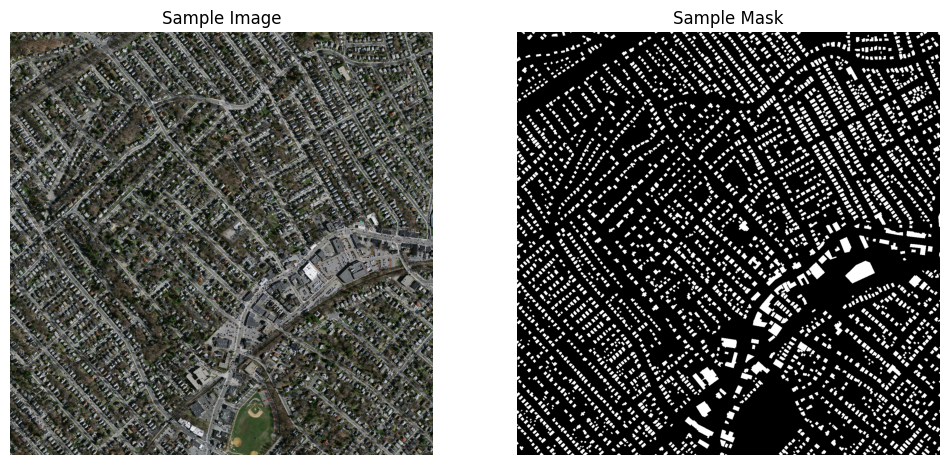

In [13]:
img_path = "/kaggle/input/massachusetts-buildings-dataset/png/test/22828930_15.png"
mask_path = "/kaggle/input/massachusetts-buildings-dataset/png/test_labels/22828930_15.png"
showImages(img_path,mask_path)

In [14]:
COLOR_MAP ={
    (0,0,0):0, #surrounding
    (255,255,255):1 #buildings
}

In [15]:
from torchvision.transforms import InterpolationMode

class BuildingDataset(Dataset):
    def __init__(self, image_path, label_path, transform=None, patch_size=448, grid_size=2):
        self.image_path = image_path
        self.label_path = label_path
        self.transform = transform
        self.patch_size = patch_size
        self.grid_size = grid_size  # 2x2 grid = 4 patches total
        self.imgs = os.listdir(image_path)

        # Store original image info for reconstruction
        self.original_sizes = {}
        self.patch_info = []  # (img_idx, patch_coords)
        
        # Precompute all patches
        self._precompute_patches()

        # label transform (NEAREST for segmentation masks!)
        self.label_transform = transforms.Compose([
            transforms.Resize((patch_size, patch_size), interpolation=InterpolationMode.NEAREST),
            transforms.PILToTensor()
        ])

    def _precompute_patches(self):
        """Precompute a fixed grid of patches"""
        self.patch_info = []
        
        for img_idx, img_name in enumerate(self.imgs):
            image_path = os.path.join(self.image_path, img_name)
            image = Image.open(image_path).convert("RGB")
            
            width, height = image.size
            self.original_sizes[img_idx] = (width, height)
            
            # Create fixed grid
            x_steps = np.linspace(0, width - self.patch_size, self.grid_size, dtype=int)
            y_steps = np.linspace(0, height - self.patch_size, self.grid_size, dtype=int)
            
            for y in y_steps:
                for x in x_steps:
                    coords = (x, y, x + self.patch_size, y + self.patch_size)
                    self.patch_info.append((img_idx, coords))

    def __len__(self):
        return len(self.patch_info)

    def __getitem__(self, idx):
        img_idx, (x1, y1, x2, y2) = self.patch_info[idx]
        img_name = self.imgs[img_idx]
        
        # Load and crop image
        image = Image.open(os.path.join(self.image_path, img_name)).convert("RGB")
        image_patch = image.crop((x1, y1, x2, y2))
        
        # Load and crop label
        label = Image.open(os.path.join(self.label_path, img_name)).convert("RGB")
        label_patch = label.crop((x1, y1, x2, y2))
        
        # Convert label to mask
        label_array = self.rgb_to_label(np.array(label_patch))
        label_patch = Image.fromarray(label_array.astype(np.uint8))

        # Apply transforms
        if self.transform:
            image_patch = self.transform(image_patch)
        
        label_patch = self.label_transform(label_patch).squeeze(0).long()

        return image_patch, label_patch

    def rgb_to_label(self, label):
        label_mask = np.zeros(label.shape[:2], dtype=np.uint8)
        for color, value in COLOR_MAP.items():
            label_mask[np.all(label == color, axis=-1)] = value
        return label_mask

    def get_original_image_info(self, idx):
        """Get original image information for a patch"""
        img_idx, coords = self.patch_info[idx]
        img_name = self.imgs[img_idx]
        return img_name, coords, self.original_sizes[img_idx]

    def get_patches_per_image(self):
        """Get number of patches per original image"""
        patches_per_image = {}
        for img_idx, img_name in enumerate(self.imgs):
            patches_per_image[img_name] = len([1 for i, c in self.patch_info if i == img_idx])
        return patches_per_image

In [16]:
IMG_SIZE = (224, 224)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

In [17]:
# Create datasets with grid sampling
train_dataset = BuildingDataset(
    train_path, 
    train_labels_path, 
    transform=train_transform,
    patch_size=224,  # Changed to match your IMG_SIZE
    grid_size=4      # 2x2 grid = 4 patches per image
)

val_dataset = BuildingDataset(
    val_path,   
    val_labels_path,   
    transform=val_transform,
    patch_size=224,
    grid_size=4
)

test_dataset = BuildingDataset(
    test_path,  
    test_labels_path,  
    transform=val_transform,
    patch_size=224,
    grid_size=4
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Print info
print(f"Total training patches: {len(train_dataset)}")
print(f"Total images: {len(train_dataset.imgs)}")
print(f"Patches per image: {train_dataset.grid_size * train_dataset.grid_size}")
print(f"Patch size: {train_dataset.patch_size}")

# Test one batch
for images, labels in train_loader:
    print(f"Batch images shape: {images.shape}")    # (16, 3, 224, 224)
    print(f"Batch labels shape: {labels.shape}")    # (16, 224, 224)
    break

Total training patches: 2192
Total images: 137
Patches per image: 16
Patch size: 224
Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16, 224, 224])


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = len(COLOR_MAP)

# **Model**

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# Basic ConvBlock (fixed)
# -------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

# -------------------------
# Choose MambaBlock implementation:
# - use real mamba_ssm.Mamba only if import succeeds AND CUDA is available
# - otherwise use convolutional fallback
# -------------------------
_use_real_mamba = False
try:
    import mamba_ssm
    # ensure CUDA is available, because the real mamba uses CUDA kernels
    if torch.cuda.is_available():
        from mamba_ssm import Mamba
        _use_real_mamba = True
    else:
        print("mamba_ssm found but CUDA is not available. Falling back to convolutional MambaBlock (CPU-safe).")
except Exception:
    # not installed or other import error
    _use_real_mamba = False

if _use_real_mamba:
    print("Using real mamba_ssm.Mamba (GPU).")

    class MambaBlock(nn.Module):
        """
        Wraps the Mamba module (requires CUDA).
        Projects channel dimension in/out so it can be used inside a conv U-Net.
        """
        def __init__(self, in_c, d_model, d_state=16, d_conv=4, expand=2):
            super().__init__()
            self.proj = nn.Linear(in_c, d_model)
            self.mamba = Mamba(d_model, d_state, d_conv, expand)
            self.norm = nn.LayerNorm(d_model)
            self.proj_out = nn.Linear(d_model, in_c)

        def forward(self, x):
            # x: (B, C, H, W)
            b, c, h, w = x.shape
            # flatten spatial dims
            x_flat = x.permute(0, 2, 3, 1).contiguous().view(b, h * w, c)
            # IMPORTANT: Mamba expects CUDA tensors; ensure x_flat is on cuda
            x_flat = x_flat.to(next(self.mamba.parameters()).device)
            x_m = self.norm(self.proj(x_flat))
            x_m = self.mamba(x_m)
            x_m = self.proj_out(x_m)
            x_out = x_m.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()
            return x_out + x

else:
    print("Using convolutional fallback MambaBlock (CPU/GPU safe).")

    class MambaBlock(nn.Module):
        """
        Lightweight convolutional approximation of the Mamba block.
        """
        def __init__(self, in_c, d_model, d_state=16, d_conv=3, expand=2):
            super().__init__()
            inner_dim = int(d_model * expand)
            self.in_proj = nn.Conv2d(in_c, inner_dim * 2, kernel_size=1, bias=False)
            self.conv_spatial = nn.Conv2d(inner_dim, inner_dim, kernel_size=d_conv, padding=d_conv//2, groups=inner_dim, bias=False)
            self.act = nn.SiLU()
            self.proj_out = nn.Conv2d(inner_dim, in_c, kernel_size=1, bias=False)

        def forward(self, x):
            residual = x
            x_in = self.in_proj(x)
            gate, conv_part = x_in.chunk(2, dim=1)
            conv_out = self.conv_spatial(conv_part)
            x_out = conv_out * torch.sigmoid(gate)
            x_out = self.proj_out(self.act(x_out))
            return x_out + residual

# -------------------------
# Full MambaUNet (U-Net style)
# -------------------------
class MambaUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2, base_channels=64):
        super().__init__()
        c = base_channels
        # Encoder
        self.conv1 = ConvBlock(in_channels, c)
        self.mamba1 = MambaBlock(c, d_model=c)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = ConvBlock(c, c*2)
        self.mamba2 = MambaBlock(c*2, d_model=c*2)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = ConvBlock(c*2, c*4)
        self.mamba3 = MambaBlock(c*4, d_model=c*4)
        self.pool3 = nn.MaxPool2d(2)

        self.conv4 = ConvBlock(c*4, c*8)
        self.mamba4 = MambaBlock(c*8, d_model=c*8)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.conv_bottleneck = ConvBlock(c*8, c*16)
        self.mamba_bottleneck = MambaBlock(c*16, d_model=c*16)

        # Decoder
        self.up4 = nn.ConvTranspose2d(c*16, c*8, kernel_size=2, stride=2)
        self.conv5 = ConvBlock(c*16, c*8)

        self.up3 = nn.ConvTranspose2d(c*8, c*4, kernel_size=2, stride=2)
        self.conv6 = ConvBlock(c*8, c*4)

        self.up2 = nn.ConvTranspose2d(c*4, c*2, kernel_size=2, stride=2)
        self.conv7 = ConvBlock(c*4, c*2)

        self.up1 = nn.ConvTranspose2d(c*2, c, kernel_size=2, stride=2)
        self.conv8 = ConvBlock(c*2, c)

        # Final conv
        self.conv_out = nn.Conv2d(c, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        c1 = self.conv1(x)
        c1 = self.mamba1(c1)
        p1 = self.pool1(c1)

        c2 = self.conv2(p1)
        c2 = self.mamba2(c2)
        p2 = self.pool2(c2)

        c3 = self.conv3(p2)
        c3 = self.mamba3(c3)
        p3 = self.pool3(c3)

        c4 = self.conv4(p3)
        c4 = self.mamba4(c4)
        p4 = self.pool4(c4)

        # Bottleneck
        cb = self.conv_bottleneck(p4)
        cb = self.mamba_bottleneck(cb)

        # Decoder
        u4 = self.up4(cb)
        if u4.shape[2:] != c4.shape[2:]:
            u4 = F.interpolate(u4, size=c4.shape[2:], mode='bilinear', align_corners=False)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv5(u4)

        u3 = self.up3(c5)
        if u3.shape[2:] != c3.shape[2:]:
            u3 = F.interpolate(u3, size=c3.shape[2:], mode='bilinear', align_corners=False)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv6(u3)

        u2 = self.up2(c6)
        if u2.shape[2:] != c2.shape[2:]:
            u2 = F.interpolate(u2, size=c2.shape[2:], mode='bilinear', align_corners=False)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv7(u2)

        u1 = self.up1(c7)
        if u1.shape[2:] != c1.shape[2:]:
            u1 = F.interpolate(u1, size=c1.shape[2:], mode='bilinear', align_corners=False)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv8(u1)

        out = self.conv_out(c8)
        return out

# -------------------------
# Smoke test (auto device selection)
# -------------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Selected device:", device)
    
    # Initialize model
    model = MambaUNet(in_channels=3, out_channels=2, base_channels=32).to(device)
    
    # Print number of trainable parameters
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of trainable parameters: {num_params:,}")
    
    # Smoke test with a dummy input
    x = torch.randn(4, 3, 224, 224).to(device)
    y = model(x)
    print("Output shape:", y.shape)  # should be (4, out_channels, 224, 224)

Using convolutional fallback MambaBlock (CPU/GPU safe).
Selected device: cuda
Number of trainable parameters: 9,876,034
Output shape: torch.Size([4, 2, 224, 224])


In [20]:
model2 = MambaUNet().to(device)
print(f"Model initialized on {device}")

Model initialized on cuda


# **Training and Testing Loop**

In [21]:
train_loss2 = []
train_acc2 = []
train_prec2 = []
train_recall2 = []
train_f12 = []
train_iou2 = []    # NEW: store train IoU per epoch
train_dice2= []   # NEW: store train Dice per epoch

val_loss2 = []
val_iou2 = []
val_dice2 = []
val_acc2 = []
val_prec2 = []
val_recall2 = []
val_f12 = []

test_loss2 = []
test_iou2 = []
test_dice2 = []
test_acc2 = []
test_prec2 = []
test_recall2 = []
test_f12 = []

In [ ]:
train_loss3 = []
train_acc3 = []
train_prec3 = []
train_recall3 = []
train_f13 = []
train_iou3 = []    # NEW: store train IoU per epoch
train_dice3= []   # NEW: store train Dice per epoch

val_loss3 = []
val_iou3 = []
val_dice3 = []
val_acc3 = []
val_prec3 = []
val_recall3 = []
val_f13 = []

test_loss3 = []
test_iou3 = []
test_dice3 = []
test_acc3 = []
test_prec3 = []
test_recall3 = []
test_f13 = []

In [ ]:
train_loss4 = []
train_acc4 = []
train_prec4 = []
train_recall4 = []
train_f14 = []
train_iou4 = []    # NEW: store train IoU per epoch
train_dice4= []   # NEW: store train Dice per epoch

val_loss4 = []
val_iou4 = []
val_dice4 = []
val_acc4 = []
val_prec4 = []
val_recall4 = []
val_f14 = []

test_loss4 = []
test_iou4 = []
test_dice4 = []
test_acc4 = []
test_prec4 = []
test_recall4 = []
test_f14 = []

In [22]:
train_model(
    model2,
    train_loader,
    val_loader,
    test_loader,
    num_epochs=30,
    device=device,
    num_classes=num_classes,
    train_loss=train_loss2,
    train_acc=train_acc2,
    train_prec=train_prec2,
    train_recall=train_recall2,
    train_f1=train_f12,
    train_iou=train_iou2,
    train_dice=train_dice2,
    val_loss=val_loss2,
    val_acc=val_acc2,
    val_prec=val_prec2,
    val_recall=val_recall2,
    val_f1=val_f12,
    val_iou=val_iou2,
    val_dice=val_dice2,
    test_loss=test_loss2,
    test_acc=test_acc2,
    test_prec=test_prec2,
    test_recall=test_recall2,
    test_f1=test_f12,
    test_iou=test_iou2,
    test_dice=test_dice2,
)

Train Epoch 1:   0%|          | 0/137 [00:00<?, ?it/s]

Val Epoch 1:   0%|          | 0/4 [00:00<?, ?it/s]

Test Epoch 1:   0%|          | 0/10 [00:00<?, ?it/s]

Train Epoch 2:   0%|          | 0/137 [00:00<?, ?it/s]

Val Epoch 2:   0%|          | 0/4 [00:00<?, ?it/s]

...

Train Epoch 30:   0%|          | 0/137 [00:00<?, ?it/s]

Val Epoch 30:   0%|          | 0/4 [00:00<?, ?it/s]

Test Epoch 30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch [30/30]
 Train -> Loss: 0.2493 | Acc: 90.1714% | Prec: 82.1282% | Rec: 67.8962% | F1: 71.9231% | IoU: 0.6147 | Dice: 0.7192
 Val   -> Loss: 0.1362 | Acc: 94.9386% | IoU: 0.7742 | Dice: 0.8617 | Prec: 88.6107% | Rec: 84.3348% | F1: 86.1698%
 Test  -> Loss: 0.2204 | Acc: 91.0121% | IoU: 0.7401 | Dice: 0.8392 | Prec: 86.7015% | Rec: 81.9995% | F1: 83.9180%
 Best so far -> Epoch: 30 | val_iou: 0.774245



'saved_models/best_model.pth'

In [23]:
print(f" Train -> Loss: {train_loss2[-1]:.4f} | Acc: {train_acc2[-1]:.4f}% | Prec: {train_prec2[-1]:.4f}% | Rec: {train_recall2[-1]:.4f}% | F1: {train_f12[-1]:.4f}% | IoU: {train_iou2[-1]:.4f} | Dice: {train_dice2[-1]:.4f}")
print(f" Val   -> Loss: {val_loss2[-1]:.4f} | Acc: {val_acc2[-1]:.4f}% | IoU: {val_iou2[-1]:.4f} | Dice: {val_dice2[-1]:.4f} | Prec: {val_prec2[-1]:.4f}% | Rec: {val_recall2[-1]:.4f}% | F1: {val_f12[-1]:.4f}%")
print(f" Test  -> Loss: {test_loss2[-1]:.4f} | Acc: {test_acc2[-1]:.4f}% | IoU: {test_iou2[-1]:.4f} | Dice: {test_dice2[-1]:.4f} | Prec: {test_prec2[-1]:.4f}% | Rec: {test_recall2[-1]:.4f}% | F1: {test_f12[-1]:.4f}%")
print("=" * 90 + "\n")

 Train -> Loss: 0.2493 | Acc: 90.1714% | Prec: 82.1282% | Rec: 67.8962% | F1: 71.9231% | IoU: 0.6147 | Dice: 0.7192
 Val   -> Loss: 0.1362 | Acc: 94.9386% | IoU: 0.7742 | Dice: 0.8617 | Prec: 88.6107% | Rec: 84.3348% | F1: 86.1698%
 Test  -> Loss: 0.2204 | Acc: 91.0121% | IoU: 0.7401 | Dice: 0.8392 | Prec: 86.7015% | Rec: 81.9995% | F1: 83.9180%



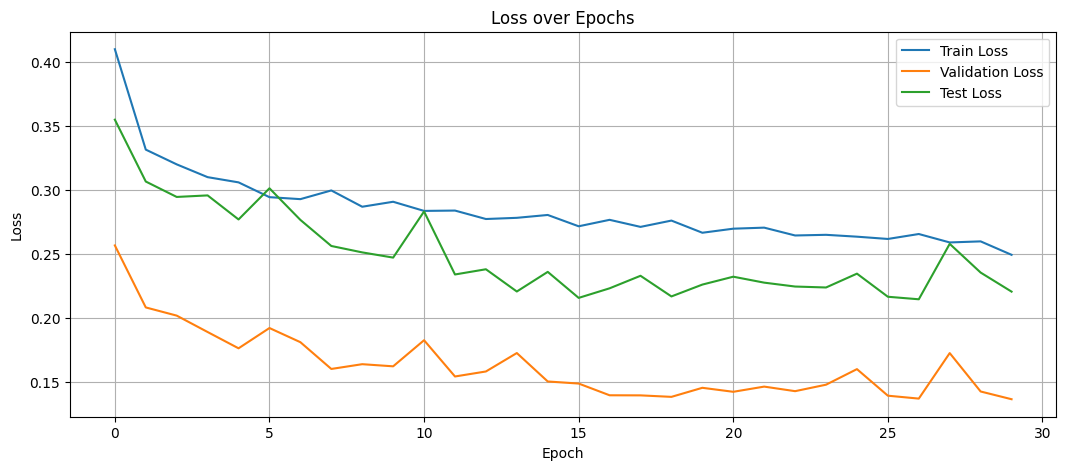

In [24]:
plt.figure(figsize=(28,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(train_loss2, label='Train Loss')
plt.plot(val_loss2, label='Validation Loss')
plt.plot(test_loss2, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

plt.show()

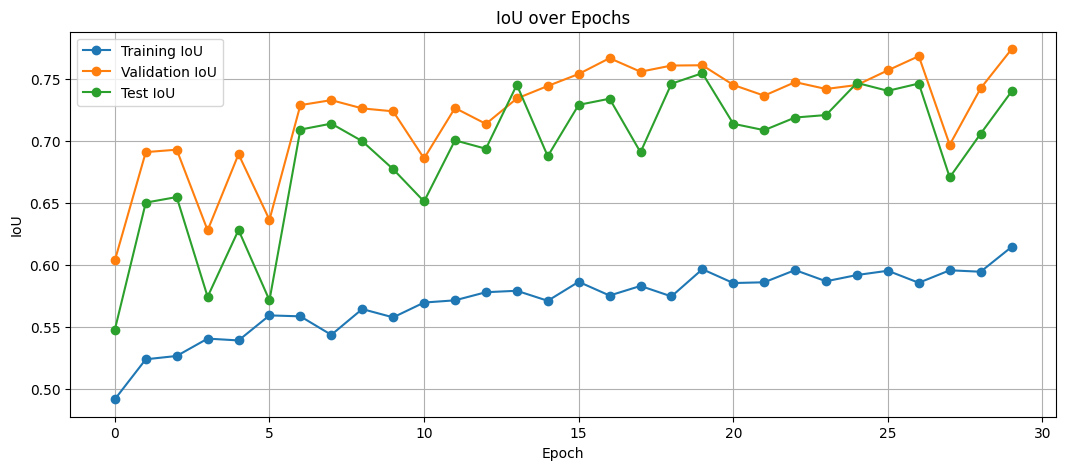

In [25]:
plt.figure(figsize=(28,5))

# IoU plot
plt.subplot(1,2,1)
plt.plot(train_iou2, label='Training IoU', marker='o')
plt.plot(val_iou2, label='Validation IoU', marker='o')
plt.plot(test_iou2, label='Test IoU', marker='o')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('IoU over Epochs')
plt.legend()
plt.grid(True)

plt.show()

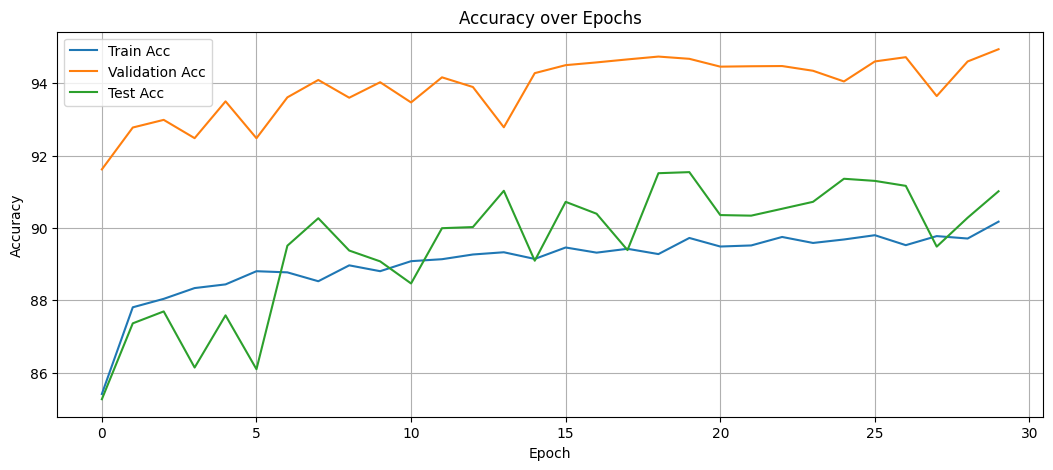

In [27]:
plt.figure(figsize=(28,5))
# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_acc2, label='Train Acc')
plt.plot(val_acc2, label='Validation Acc')
plt.plot(test_acc2, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

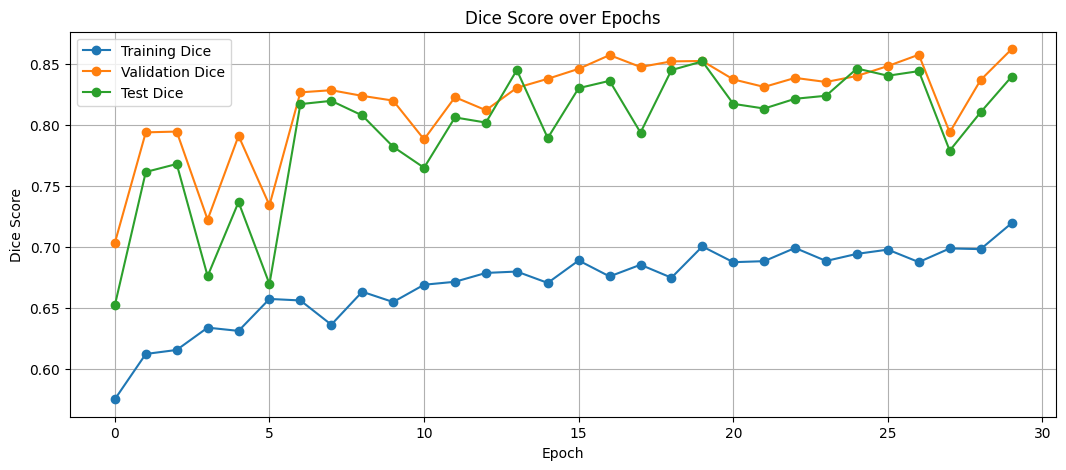

In [28]:
plt.figure(figsize=(28,5))
# Dice plot
plt.subplot(1,2,2)
plt.plot(train_dice2, label='Training Dice', marker='o')
plt.plot(val_dice2, label='Validation Dice', marker='o')
plt.plot(test_dice2, label='Test Dice', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.title('Dice Score over Epochs')
plt.legend()
plt.grid(True)
plt.show()

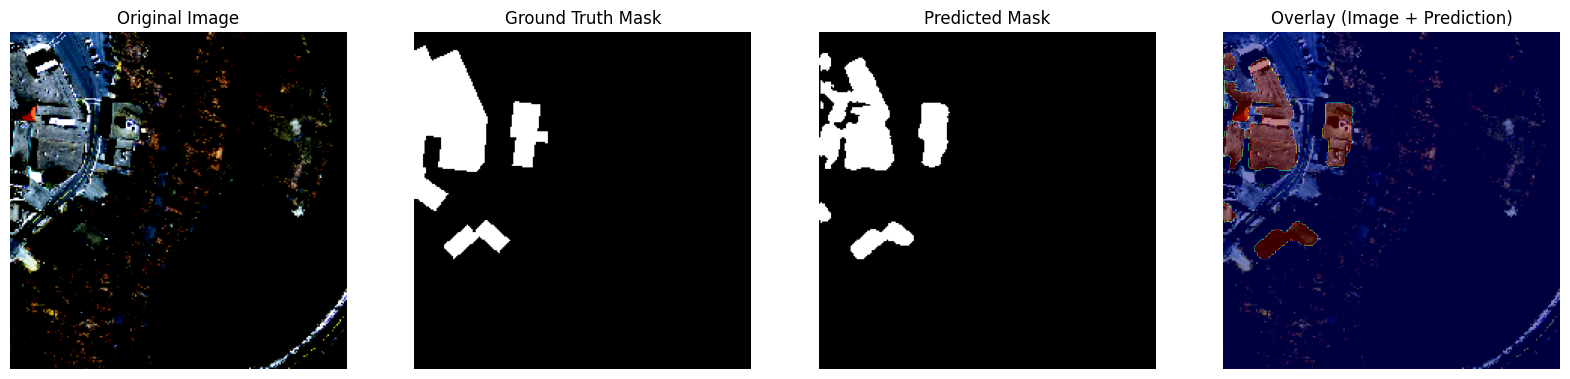

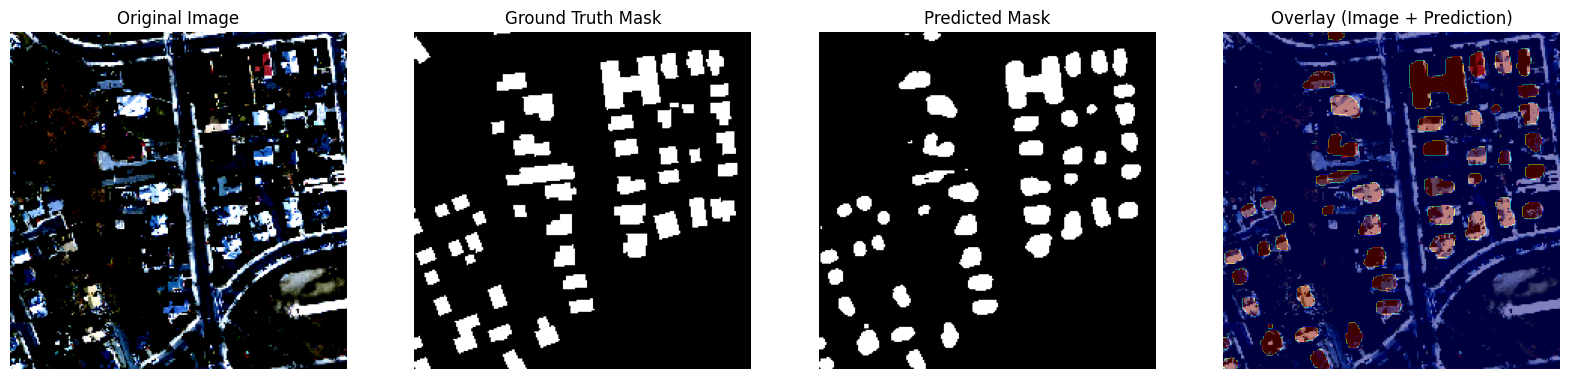

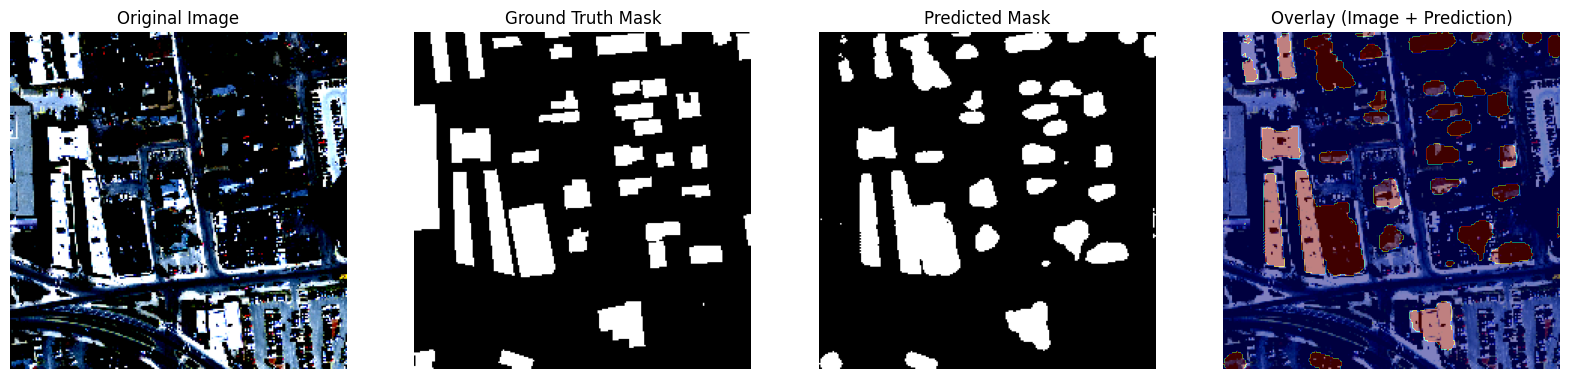

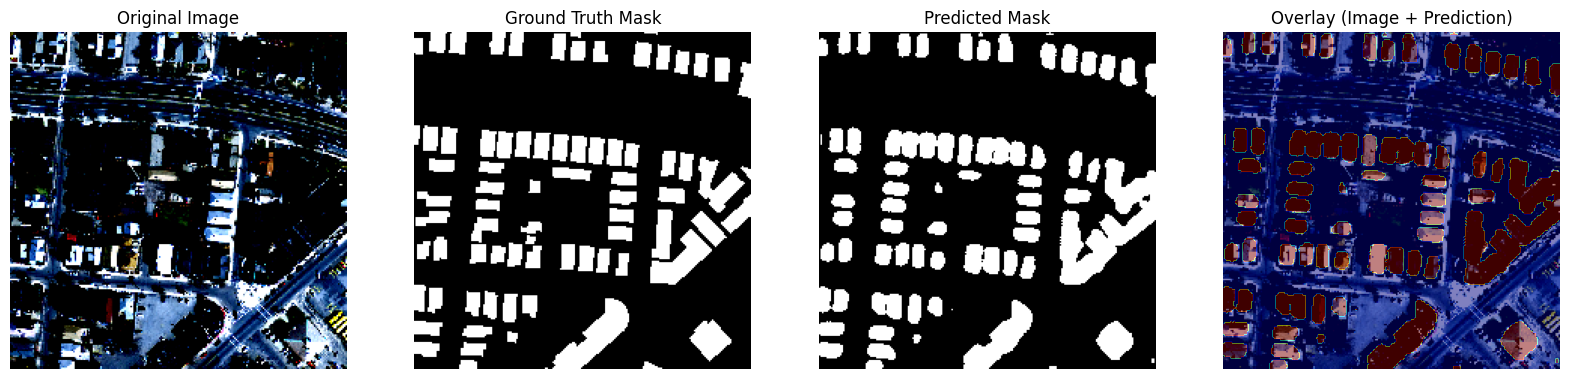

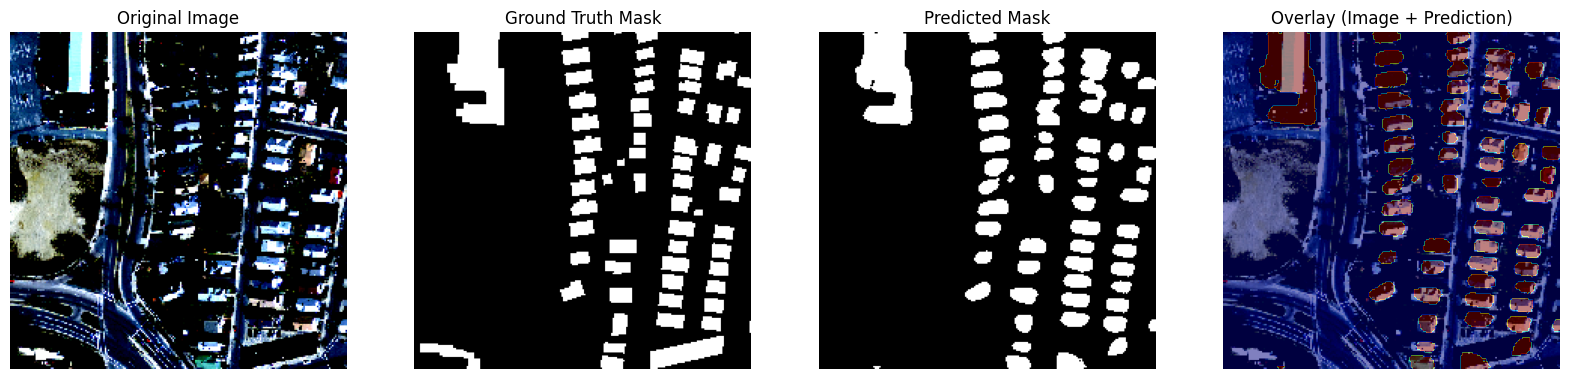

In [35]:
show_image_gt_pred(test_dataset, model2, idx=1, device=device)
show_image_gt_pred(test_dataset, model2, idx=2, device=device)
show_image_gt_pred(test_dataset, model2, idx=3, device=device)
show_image_gt_pred(test_dataset, model2, idx=4, device=device)
show_image_gt_pred(test_dataset, model2, idx=5, device=device)

In [36]:
ckpt = load_checkpoint(model2, "saved_models/best_model.pth", device="cuda")
model2.eval()

MambaUNet(
  (conv1): ConvBlock(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (mamba1): MambaBlock(
    (in_proj): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (conv_spatial): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
    (act): SiLU()
    (proj_out): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): ConvBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, a

In [37]:
from torchinfo import summary
summary(model, input_size=(4, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
MambaUNet                                [4, 2, 224, 224]          --
├─ConvBlock: 1-1                         [4, 32, 224, 224]         --
│    └─Conv2d: 2-1                       [4, 32, 224, 224]         864
│    └─BatchNorm2d: 2-2                  [4, 32, 224, 224]         64
│    └─ReLU: 2-3                         [4, 32, 224, 224]         --
│    └─Conv2d: 2-4                       [4, 32, 224, 224]         9,216
│    └─BatchNorm2d: 2-5                  [4, 32, 224, 224]         64
│    └─ReLU: 2-6                         [4, 32, 224, 224]         --
├─MambaBlock: 1-2                        [4, 32, 224, 224]         --
│    └─Conv2d: 2-7                       [4, 128, 224, 224]        4,096
│    └─Conv2d: 2-8                       [4, 64, 224, 224]         576
│    └─SiLU: 2-9                         [4, 64, 224, 224]         --
│    └─Conv2d: 2-10                      [4, 32, 224, 224]         2,048
├─Ma

In [38]:
!pip install fvcore
from fvcore.nn import FlopCountAnalysis

input_tensor = torch.randn(1, 3, 224, 224).to(device)
flops = FlopCountAnalysis(model, input_tensor)
print("FLOPs:", flops.total())
print("FLOPs (in GigaFLOPs):", flops.total() / 1e9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=9a083ba3ef5e871d7b264950d0a87da78ff3fde64f7a92d1ee6c8f53456d3286
  Stored in directory: /root/.cache/pip/wheels/65/71/95/3b8fde5c65c6e4a806e0867c1651dcc71a1cb2f3430e8f355f
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=12c20aad5296a64668ef45c2a0cd1aafc48b8a2f1c51af660e905d738a838509
  Stored in directory: /root/.cache/pip/wheels/ba/5e/16/6117f8fe7e9c0c161a795e10d94645ebcf301ccbd01f66d8ec
Successfully built fvcore iopath
FLOPs: 10902241280
FLOPs (in GigaFLOPs): 10.90224128


In [40]:
per_sample_times = measure_dataloader(model, val_loader, device=device, warmup_batches=5, n_batches=None)
print("median (ms):", np.median(per_sample_times)*1000)
print("p90 (ms):", np.percentile(per_sample_times, 90)*1000)
print("throughput (samples/sec):", 1.0 / per_sample_times.mean())


[measure_dataloader] device=cuda, batches_measured=4, total_samples_measured=64
[measure_dataloader] reported loader_len=4
[measure_dataloader] warmup_batches=5, requested_n_batches=None
median (ms): 8.681665718768272
p90 (ms): 8.685597062481065
throughput (samples/sec): 121.57469933240866


In [41]:
overall_accuracy = val_acc2[-1]  # last epoch or best one
print("Overall Accuracy (OA):", overall_accuracy)

Overall Accuracy (OA): 94.9386285275829


In [43]:
import numpy as np

best_epoch = np.argmax(val_prec2)  # or val_dice
print(f"Best Epoch: {best_epoch+1}")
print(f"Val Accuracy: {val_acc2[best_epoch]:.4f}")
print(f"Val IoU: {val_iou2[best_epoch]:.4f}")
print(f"Val Dice: {val_dice2[best_epoch]:.4f}")
print(f"Val Precession: {val_prec2[best_epoch]:.4f}")

Best Epoch: 29
Val Accuracy: 94.6001
Val IoU: 0.7427
Val Dice: 0.8365
Val Precession: 91.0239


In [44]:
import numpy as np

best_epoch = np.argmax(val_iou2)  # or val_dice
print(f"Best Epoch: {best_epoch+1}")
print(f"Val Accuracy: {val_acc2[best_epoch]:.4f}")
print(f"Val IoU: {val_iou2[best_epoch]:.4f}")
print(f"Val Dice: {val_dice2[best_epoch]:.4f}")

Best Epoch: 30
Val Accuracy: 94.9386
Val IoU: 0.7742
Val Dice: 0.8617
